In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import os
from discodj import DiscoDJ 

import sys
sys.path.insert(0, '/home/phuy2808/Astrophysis/intern_lmu')

from polybin3d_tspec.base import PolyBin3D
from polybin3d_tspec.pspec import PSpec
from polybin3d_tspec.bspec import BSpec

In [2]:
BOXSIZE = 400.0
RES = 128
k_f = 2 * np.pi / BOXSIZE
k_max = 0.4
bin_edges = np.linspace(k_f, k_max, 21)

k_log = 0.5*(bin_edges[1:] + bin_edges[:-1])

DEVICE  = 'gpu' if any(d.platform=='gpu' for d in jax.devices()) else 'cpu'

theta = [0.30, 0.05, 0.65, 1.00, 0.80]
Oc, Ob, h, ns, s8 = theta

In [3]:
dj = DiscoDJ(dim=3, res=RES, name='tspec_val', device=DEVICE, precision='single', boxsize=BOXSIZE, cosmo=dict(Omega_c=Oc, Omega_b=Ob, h=h, n_s=ns, sigma8=s8))
dj = dj.with_timetables().with_linear_ps(transfer_function='Eisenstein-Hu')
wnf = dj.get_ngenic_noise(seed=42)
dj  = dj.with_ics(white_noise_space='real', white_noise_field=wnf, convert_to_numpy=True)
dj  = dj.with_lpt(n_order=2, convert_to_numpy=True)
X, _, _ = dj.run_nbody(a_ini=0.02, a_end=1.0, n_steps=10, res_pm=2*RES,
                        time_var='D', stepper='bullfrog', method='pm', antialias=0,
                        grad_kernel_order=4, laplace_kernel_order=0, nlpt_order_ics=2,
                        n_resample=1, deconvolve=False, return_displacement=False,
                        chunk_size=None, convert_to_numpy=True)
delta = np.asarray(dj.get_delta_from_pos(X, res=RES, worder=2,
                                        deconvolve=False, antialias=False), dtype=np.float64)


In [4]:
_, Pk_dj, _ = dj.evaluate_power_spectrum(delta, bins=tuple(bin_edges),  deconvolve=False, worder = 2, logarithmic = False)
Pk_dj = np.asarray(Pk_dj, dtype=np.float64)

In [5]:
base = PolyBin3D(boxsize = BOXSIZE, gridsize= RES, Pk = None, pixel_window = 'none', backend = 'jax', sightline = 'global', real_fft = True)
pspec = PSpec(base, k_bins = bin_edges, lmax = 0)

fisher_ideal = pspec.compute_fisher_ideal()

Pk_polybin = np.asarray(pspec.Pk_ideal(delta, fish_ideal=fisher_ideal)).reshape(-1)
k_polybin = np.asarray(pspec.get_ks()).reshape(-1)[:len(Pk_polybin[0]['p0'])]


# Dimensions: [4.00e+02, 4.00e+02, 4.00e+02] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [128, 128, 128]
# Fundamental frequency: [0.0157, 0.0157, 0.0157] h/Mpc
# Nyquist frequency: [1.005, 1.005, 1.005] h/Mpc
# Pixel window: none
# Using JAX backend

Binning: 20 bins in [0.016, 0.400] h/Mpc
l-max: 0
Mask: constant
Computing ideal Fisher matrix


In [8]:
k_polybin

array([0.02531526, 0.04452987, 0.06374447, 0.08295907, 0.10217367,
       0.12138827, 0.14060288, 0.15981748, 0.17903208, 0.19824668,
       0.21746128, 0.23667588, 0.25589049, 0.27510509, 0.29431969,
       0.31353429, 0.33274889, 0.3519635 , 0.3711781 , 0.3903927 ])

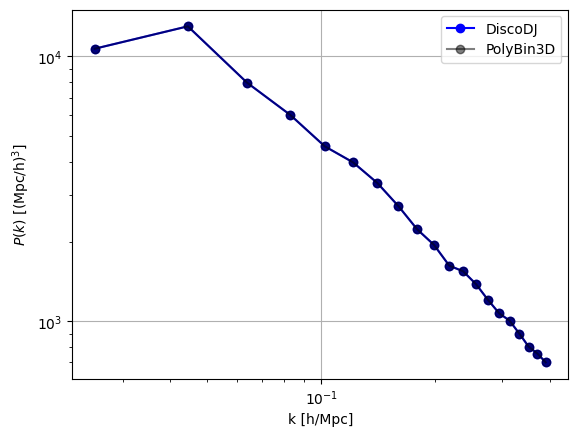

In [9]:
plt.loglog(k_log, Pk_dj, 'bo-', label='DiscoDJ')
plt.loglog(k_polybin, Pk_polybin[0]['p0'], 'ko-', label='PolyBin3D', alpha=0.5)
plt.xlabel(r'k [h/Mpc]')
plt.ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
plt.legend()
plt.grid()
#plt.savefig('power_spectrum_comparison.png', dpi=300)

In [6]:
bin_coarse = np.linspace(k_f, 0.2, 8)
bspec = BSpec(base, k_bins = bin_coarse, lmax = 0)

fisher_ideal = bspec.compute_fisher_ideal()

Bk_polybin = np.asarray(bspec.Bk_ideal(delta, fish_ideal=fisher_ideal)).reshape(-1)
tri = np.asarray(bspec.get_ks()).T


Binning: 7 bins in [0.016, 0.200] h/Mpc
l-max: 0
N_bins: 62
Mask: constant
Computing degeneracy factor
Computing ideal Fisher matrix


In [11]:
Bd = dj.evaluate_bispectrum(delta, bins=tuple(bin_coarse), deconvolve=False, worder = 2,  only_B = False)
Bk_dj = np.asarray(Bd['Bk'])
k_dj = np.asarray(Bd['k'])

In [12]:
eq = lambda k: np.isclose(k[:,0], k[:,1]) & np.isclose(k[:,1], k[:,2])
tri_eq = tri[eq(tri), 0]
k_dj_eq = k_dj[eq(k_dj), 0]

In [13]:
Bk_dj

array([-8.67651732e+07,  5.43581640e+08,  4.62097508e+08,  2.48044122e+08,
        5.23909242e+08,  2.16885897e+08,  1.60156266e+07,  7.21355628e+07,
        7.85472411e+07,  3.03750729e+07,  8.31919069e+08,  2.02688630e+08,
        2.15804694e+08,  9.88011728e+07,  7.02188018e+07,  1.87778522e+08,
        1.10245571e+08,  4.74383747e+07,  5.35054272e+07,  3.03088365e+08,
        2.07187942e+08,  1.36129584e+08,  9.33847867e+07,  1.23043447e+08,
        6.20668852e+07,  4.28620039e+07,  2.11703250e+07,  1.08179358e+08,
        5.77976230e+07,  3.63639242e+07,  2.01299892e+07,  4.24550245e+07,
        1.47365334e+08,  1.06024547e+08,  2.40044612e+08,  9.92210903e+07,
        6.86181417e+07,  4.19799901e+07,  1.57207202e+08,  8.04864383e+07,
        3.78089457e+07,  2.75181415e+07,  2.04200857e+07,  1.24700396e+08,
        6.59136647e+07,  3.94845056e+07,  2.31612624e+07,  2.60464386e+07,
        2.52761166e+07,  1.05675633e+08,  4.77707593e+07,  8.40584545e+07,
        4.53327720e+07,  

In [14]:
Bk_polybin[0]['b0'][eq(tri)]

array([-8.67651732e+07,  2.48044122e+08,  3.03750729e+07,  5.35054272e+07,
        4.24550245e+07,  2.52761166e+07,  1.22551986e+07])

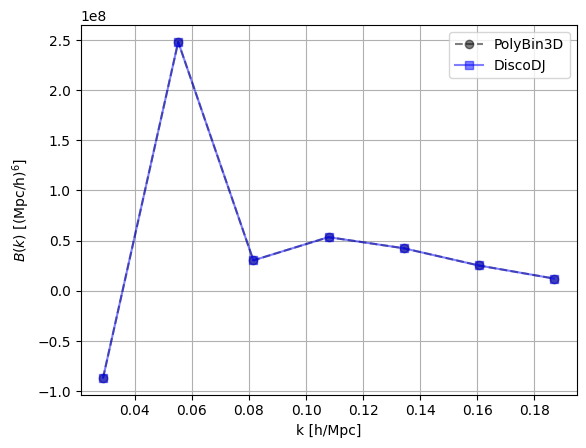

In [15]:
plt.plot(tri_eq, Bk_polybin[0]['b0'][eq(tri)], 'ko--', label='PolyBin3D', alpha=0.5)
plt.plot(k_dj_eq, Bk_dj[eq(k_dj)], 'bs-', label='DiscoDJ', alpha=0.5)
plt.xlabel(r'k [h/Mpc]')
plt.ylabel(r'$B(k)$ [(Mpc/h)$^6$]')
plt.legend()
plt.grid()

## test trispectrum

In [7]:
import importlib 
import polybin3d_tspec.tspec as tspec
importlib.reload(tspec)

<module 'polybin3d_tspec.tspec' from '/home/phuy2808/Astrophysis/intern_lmu/polybin3d_tspec/tspec.py'>

In [8]:
ts = tspec.TSpec(base, k_bins = bin_coarse, diag_bins=bin_coarse, shapes = [])
g = ts._process_sim(delta) 
print("n shell maps:", len(g), "each of shape:", g[0].shape)


n shell maps: 7 each of shape: (128, 128, 128)


In [9]:
recon = sum(g) 
band = base.to_real(base.map_utils.fourier_filter(base.to_fourier(delta), 0, bin_coarse[0], bin_coarse[-1]))
err = np.max(np.abs(recon - band)/np.max(np.abs(band))) 
err

np.float64(3.0350583010957213e-16)

In [10]:
nk = len(bin_coarse) - 1
shapes = tspec.TSpec.equal_pair_shapes(nk)
ts = tspec.TSpec(base, k_bins = bin_coarse, diag_bins=bin_coarse, shapes = shapes) 

t = ts.Tk_numerator(delta)


In [11]:
#swap symmetry, let t[(i,i,j,j)] = t[(j, j, i, i)]

idx = {sh: n for n, sh in enumerate(shapes)}
maxrel = 0 
for (i, _i, j, _j) in shapes:
    s2 = (j, j, i, i)
    if s2 in idx: 
        a,b = t[idx[i,i,j,j]], t[idx[s2]]
        maxrel = max(maxrel, np.max(np.abs(a - b))/np.max(np.abs(a)) + 1e-30)
        

In [12]:
N = 30
acc = 0.0
for s in range(N):
    grf = base.generate_data(seed = 1000+s, Pk_input= [], output_type = 'real')
    acc += ts.Tk_numerator(grf)
tmean = acc/N

In [13]:
off = [n for n,(i,_i,j,_j) in enumerate(shapes) if i!= j]
on = [n for n,(i,_i,j,_j) in enumerate(shapes) if i== j]

print("i!=j  mean|t| per K-bin:", np.abs(tmean[off]).mean(0))
print("i==j  mean|t| per K-bin:", np.abs(tmean[on]).mean(0))
print("ratio off/on per K-bin:", np.abs(tmean[off]).mean(0) / np.abs(tmean[on]).mean(0))


i!=j  mean|t| per K-bin: [6.90592677e-07 6.55306523e-07 4.83249395e-07 5.61172732e-07
 4.25930358e-07 4.26057086e-07 3.07038998e-07]
i==j  mean|t| per K-bin: [4.44345741e-05 7.62431674e-05 1.17387148e-04 1.50733867e-04
 1.76524028e-04 2.22217813e-04 2.41492723e-04]
ratio off/on per K-bin: [0.01554179 0.00859495 0.00411671 0.00372294 0.00241287 0.00191729
 0.00127142]


In [14]:
ts = tspec.TSpec(base, k_bins = bin_coarse, diag_bins=bin_coarse, shapes = shapes)


In [15]:
N = ts._mode_counts()
T_id = ts.Tk_ideal(delta)

In [16]:
print("N shape:", N.shape, "| min:", N.min(), "| frac zero:", np.mean(N == 0))
print("N summed over shapes, per K-bin:", N.sum(0))

N shape: (28, 7) | min: -2.8788449250224005e-29 | frac zero: 0.0
N summed over shapes, per K-bin: [8.22452217e-11 7.37863080e-11 7.60061643e-11 7.39604064e-11
 6.81096839e-11 7.08093625e-11 6.38639890e-11]


In [17]:
print("Tk_ideal finite:", np.all(np.isfinite(T_id)))
print("Tk_ideal i==j, K-bin0:", T_id[[n for n,(i,_i,j,_j) in enumerate(shapes) if i==j], 0])


Tk_ideal finite: True
Tk_ideal i==j, K-bin0: [2.95619600e+16 1.01783691e+16 1.37402316e+15 5.79930046e+14
 2.22794111e+14 1.78990015e+14 6.05720811e+13]


In [18]:
print("frac configs zeroed:", np.mean(T_id == 0))
print("max |Tk_ideal|:", np.abs(T_id).max())
s0 = shapes.index((0,0,0,0))  
print("Tk_ideal[(0,0,0,0), all K]:", T_id[s0])

frac configs zeroed: 0.20408163265306123
max |Tk_ideal|: 6.800463621861428e+17
Tk_ideal[(0,0,0,0), all K]: [2.95619600e+16 1.01335848e+17 6.80046362e+17 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [19]:
t_new = ts.Tk_numerator(delta)
g = ts._process_sim(delta)
t_direct = ts._numerator(g, g, g, g)

print("match:", np.allclose(t_new, t_direct))
print("finite:", np.all(np.isfinite(t_new)), "shape:", t_new.shape)

match: True
finite: True shape: (28, 7)


In [20]:
Tc_sims = []
for s in range(50):
    grf = base.generate_data(seed = 20000 +s, Pk_input =[], output_type = 'real')
    Tc_sims.append(grf)
Tc_sims = np.array(Tc_sims)

In [21]:
mean = Tc_sims.mean(0)
err = Tc_sims.std(0) / np.sqrt(len(Tc_sims))
m = np.where(err > 0)
pull = np.zeros_like(mean); pull[m] = mean[m]/err[m]
print("max |pull|:", np.nanmax(np.abs(pull)))
print("mean pull :", pull[m].mean())
print("frac |pull|>3:", np.mean(np.abs(pull[m])>3))


max |pull|: 5.519053565387168
mean pull : 1.8972740163306046e-05
frac |pull|>3: 0.004649162292480469


In [23]:
tp.check_mode_counts(ts)

no reference at output/N_tri_actual.npy


In [1]:
import numpy as np

In [2]:
def make_window(nmesh, boxsize, cap_costheta = 0.5, r_min = 0.1, r_max = 0.45, center = (0.5, 0.5, 0.5), observer = (0.5, 0.5, 0.0)):
    """survey mask W(x) in [0,1]: angular cap x radial n(z) taper"""
    cell = boxsize / nmesh
    x = (np.arange(nmesh) + 0.5) * cell
    X,Y,Z = np.meshgrid(x, x, x, indexing='ij')
    obs = np.array(observer) * boxsize
    dx , dy, dz = X - obs[0], Y - obs[1], Z - obs[2]

    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r = np.maximum(r, 1e-6)  # avoid divide by zero

    center = np.array(center) * boxsize
    axis = (center - obs) / np.linalg.norm(center - obs)
    axis /= np.linalg.norm(axis)   # unit vector 

    costheta = (dx*axis[0] + dy*axis[1] + dz*axis[2]) / r
    
    ang = 0.5*(1 + np.tanh((costheta - cap_costheta)/0.05))

    w_r = 0.03*boxsize 

    taper = 0.5*(1 + np.tanh((r - r_min*boxsize)/w_r)) * 0.5*(1 + np.tanh((r_max*boxsize - r)/w_r))
    W = ang * taper
    return W

In [3]:
W = make_window(128, 400.0)
assert W.shape == (128, 128, 128)
assert np.all(W >= 0) and np.all(W <= 1)
fvol = W.mean()
print("volume fraction of survey mask:", fvol)


volume fraction of survey mask: 0.09519245190280547


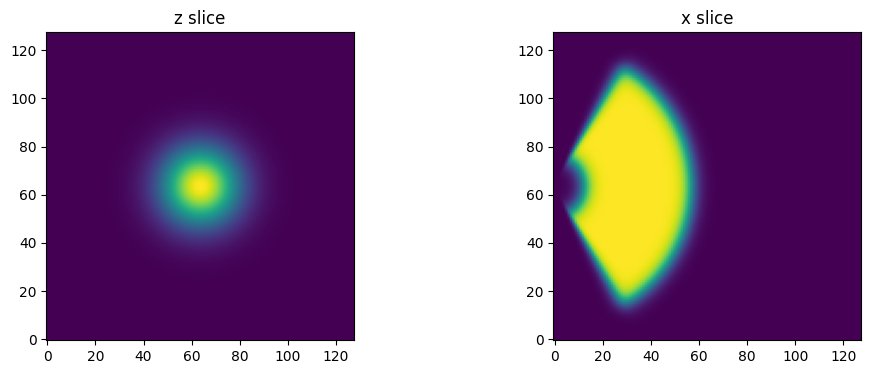

In [4]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2, figsize=(12,4))
ax[0].imshow(W[:,:,64], origin='lower') 
ax[0].set_title('z slice')
ax[1].imshow(W[64,:,:], origin='lower')
ax[1].set_title('x slice')
plt.show()

In [5]:
Wk = np.fft.fftn(W)
Pk_W = np.abs(Wk)**2

In [6]:
def sample_catalog(delta, W, nbar, boxsize, rng):
    """poisson galaxies from n(x) = nbar * W(x) *()1 + delta(x))"""

    n_x = np.where((1 + delta) > 0, nbar * W * (1 + delta), 0)
    
    nmesh = delta.shape[0]
    V = (boxsize/nmesh)**3

    mean_counts = n_x * V
    N = rng.poisson(mean_counts)

    idx = np.argwhere(N > 0)
    counts = N[N > 0]
    cells = np.repeat(idx, counts, axis=0)
    jitter = rng.random(cells.shape)
    pos = (cells + jitter) * (boxsize/nmesh)
    return pos




In [7]:
rng = np.random.default_rng(0)
cat = sample_catalog(np.zeros((128,)*3), W, nbar = 1e-3, boxsize = 400, rng = rng)
expected = 1e-3 * W.mean() *400.0**3

print(f"Expected number of galaxies: {expected}")
print(len(cat))

Expected number of galaxies: 6092.316921779549
6088


In [8]:
cell = 400.0 / 128
ijk = (cat/cell).astype(int)
assert((W[ijk[:,0], ijk[:,1], ijk[:,2]] > 0).all())